# Set env

In [1]:
import scanpy as sc
import numpy as np
import gc
import pandas as pd
import anndata as ad
import time
import h5py
from scipy.spatial.distance import cdist
import os
import seaborn as sns
import psutil
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix,save_npz
from tqdm import tqdm
from pyALRA import choose_k,alra,normalize_data
from itertools import combinations
from sklearn.metrics import mean_squared_error

# Compare test data from ALRA Package

In [4]:
r_data_norm=pd.read_csv('/storage/Implem/pyALRA_package/pyALRA/data/data_test_normed_R.csv',sep=' ')
r_data_norm

,AL627309.1,RP11-206L10.2,LINC00115,NOC2L,KLHL17,HES4,ISG15,C1orf159,TTLL10,TNFRSF18,...,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB,AL592183.1,AC011841.1,PNRC2,SRSF10.1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,2.499236,0.000000,0.0,2.134023,0.0,0.0,0.0,1.552739
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,1.696049,1.696049,0.0,3.470926,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,1.873284,0.0,0.0,0.000000,...,0.000000,0.000000,3.351594,1.873284,0.0,3.528061,0.0,0.0,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,2.323182,0.000000,2.966108,2.966108,0.0,3.633166,0.0,0.0,0.0,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,2.520524,1.904724,0.0,3.564034,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16422,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,1.948314,0.000000,1.948314,2.567538,0.0,2.947096,0.0,0.0,0.0,0.000000
16423,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.841349,...,3.101000,0.000000,2.828208,2.451874,0.0,2.451874,0.0,0.0,0.0,0.000000
16424,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,2.614342,1.991855,2.995099,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
16425,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,2.356230,...,1.753633,0.000000,3.538895,1.753633,0.0,3.389573,0.0,0.0,0.0,0.000000


In [5]:
adata_norm=ad.AnnData(r_data_norm)
adata_norm

/home/alexandre_lanau/miniconda3/envs/sc_gex_tcr_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 16427 × 12776

In [7]:
k = choose_k(adata_norm.X)
print(k['k'])

13


In [8]:
adata_norm.layers['alra'] = alra(adata_norm.X, k['k'])['A_norm_rank_k_cor_sc']

Read matrix with 16427 cells and 12776 genes
Find the 0.001 quantile of each gene
Sweep


/home/alexandre_lanau/miniconda3/envs/sc_gex_tcr_env/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alexandre_lanau/miniconda3/envs/sc_gex_tcr_env/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/alexandre_lanau/miniconda3/envs/sc_gex_tcr_env/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/storage/Implem/pyALRA_package/pyALRA/core.py:86: RuntimeWarning: invalid value encountered in divide
  mu_1 = np.sum(A_norm_rank_k_cor, axis=0) / np.sum(A_norm_rank_k_cor != 0, axis=0)
/storage/Implem/pyALRA_package/pyALRA/core.py:87: RuntimeWarning: invalid value encountered in divide
  mu_2 = np.sum(A_norm, axis=0) / np.sum(A_norm != 0, axis=0)


Scaling all except for 244 columns
0.00% of the values became negative in the scaling process and were set to zero
The matrix went from 5.11% nonzero to 76.13% nonzero


In [9]:
r_data=pd.read_csv('/storage/Implem/pyALRA_package/pyALRA/data/data_test_processed_R.csv',sep=' ',header=None)

/tmp/ipykernel_2933945/1720561812.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261

In [10]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(adata_norm.layers['alra'],np.array(r_data.drop(index=0),dtype='float'))
print(mse)

0.07668368224948025


# Benchmarks

In [2]:
adata=sc.datasets.ebi_expression_atlas(accession='E-GEOD-139324')
adata

AnnData object with n_obs × n_vars = 157689 × 25184
    obs: 'Sample Characteristic[organism]', 'Sample Characteristic Ontology Term[organism]', 'Sample Characteristic[individual]', 'Sample Characteristic Ontology Term[individual]', 'Sample Characteristic[sex]', 'Sample Characteristic Ontology Term[sex]', 'Sample Characteristic[ethnic group]', 'Sample Characteristic Ontology Term[ethnic group]', 'Sample Characteristic[age]', 'Sample Characteristic Ontology Term[age]', 'Sample Characteristic[disease]', 'Sample Characteristic Ontology Term[disease]', 'Sample Characteristic[infection]', 'Sample Characteristic Ontology Term[infection]', 'Sample Characteristic[sampling site]', 'Sample Characteristic Ontology Term[sampling site]', 'Sample Characteristic[tumor grading]', 'Sample Characteristic Ontology Term[tumor grading]', 'Sample Characteristic[organism part]', 'Sample Characteristic Ontology Term[organism part]', 'Sample Characteristic[cell type]', 'Sample Characteristic Ontology Term[cell

## Randomized_svd iteration

In [ ]:
from tqdm import tqdm

q_values = [1, 2, 5, 10, 20, 30, 50, 100]
n_repeats = 5  

k_results = {q: [] for q in q_values}


for q in tqdm(q_values, desc="Running choose_k for different q"):
    for _ in range(n_repeats):
        k = choose_k(adata.X, q=q)  
        k_results[q].append(k['k'])     


k_means = []
k_stds = []

for q in q_values:
    values = np.array(k_results[q])
    k_means.append(np.mean(values))
    k_stds.append(np.std(values))

plt.figure(figsize=(8, 5))
plt.plot(q_values, k_stds, marker='o', label='Std of k')
plt.xlabel('Number of iterations (q)')
plt.ylabel('Standard Deviation of k')
plt.title('Stability of k with Increasing Iterations q')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("std_k_vs_q.pdf", dpi=300)
plt.close()

Running choose_k for different q:  75%|███████▌  | 6/8 [1:24:53<42:06, 1263.46s/it]

## Computational ressources

In [ ]:
import time
import psutil
import h5py
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

def benchmark_alra_py(adata, cell_counts, num_runs, output_dir):
    # Prepare lists to store results
    cpu_hours = []
    memory_usage = []
    execution_time = []
    k_values = []
    percent_non_zero = []
    n_cells_list=[]
    runs=[]

    for n_cells in cell_counts:
        adata_subset = adata[:n_cells, :].copy()
        adata_subset.X = normalize_data(adata_subset.X.toarray())
        adata_subset.write(output_dir+'E-GEOD-139324_{}_cells.h5ad'.format(n_cells))
        for run in range(num_runs):
            random_state=random.randint(0, 10000)
            print(random_state)
            # Start monitoring
            process = psutil.Process()
            start_time = time.time()
            start_memory = process.memory_info().rss / (1024 * 1024)  # Memory in MB
            start_cpu_time = process.cpu_times().user + process.cpu_times().system  # Total CPU time in seconds

            # Run ALRA
            k = choose_k(adata_subset.X,random_state=random_state,type=None)
            print(f"Run {run + 1}, Cells: {n_cells}, k: {k['k']}")
            adata_subset.layers['alra'] = alra(adata_subset.X, k['k'],random_state=random_state,type=None)['A_norm_rank_k_cor_sc']

            # Stop monitoring
            end_time = time.time()
            end_memory = process.memory_info().rss / (1024 * 1024)
            end_cpu_time = process.cpu_times().user + process.cpu_times().system  # Total CPU time in seconds

            # Calculate metrics
            cpu_time_seconds = end_cpu_time - start_cpu_time
            cpu_time_hours = cpu_time_seconds / 3600  # Convert to hours
            cpu_hours.append(cpu_time_hours)
            memory_usage.append(end_memory - start_memory)
            execution_time.append(end_time - start_time)
            k_values.append(k['k'])
            n_cells_list.append(n_cells)
            runs.append(run + 1)

            # Calculate the percentage of non-zero values
            num_non_zero = np.count_nonzero(adata_subset.layers['alra'])
            total_values = adata_subset.layers['alra'].size
            non_zero_percentage = (num_non_zero / total_values) * 100
            percent_non_zero.append(non_zero_percentage)
            adata_subset.write(output_dir+'bench_runs/'+'E-GEOD-139324_run_{}_cells_{}_alra.h5ad'.format(run,n_cells))
            # Clear memory after each run
        process_memory_cleanup()

    # Create a DataFrame to store the results
    results_df = pd.DataFrame({
        'Run': runs,
        'Number_of_Cells': n_cells_list,
        'k': k_values,
        'Percent_Non_Zero': percent_non_zero,
        'CPU_Hours': cpu_hours,
        'Memory_Usage_MB': memory_usage,
        'Execution_Time_s': execution_time
    })

    # Save the results to a CSV file
    results_csv = f"{output_dir}alra_benchmark_results.csv"
    results_df.to_csv(results_csv, index=False)

    print(f"Results saved to {results_csv}")

    return results_df

def process_memory_cleanup():
    """Performs memory cleanup by running garbage collection."""
    gc.collect()

# Example usage
cell_counts = [ 1000,10000, 50000#, 100000
               ]  # Adjust based on your data
num_runs = 5
output_dir = "/storage/Implem/pyALRA_package/pyALRA/alra_benchmark_results/python/E-GEOD-139324/"

# Ensure the output directory exists
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

results = benchmark_alra_py(adata, cell_counts, num_runs, output_dir)


/tmp/ipykernel_49321/614381598.py:39: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(
/tmp/ipykernel_49321/614381598.py:39: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(
/tmp/ipykernel_49321/614381598.py:48: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/tmp/ipykernel_49321/614381598.py:48: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


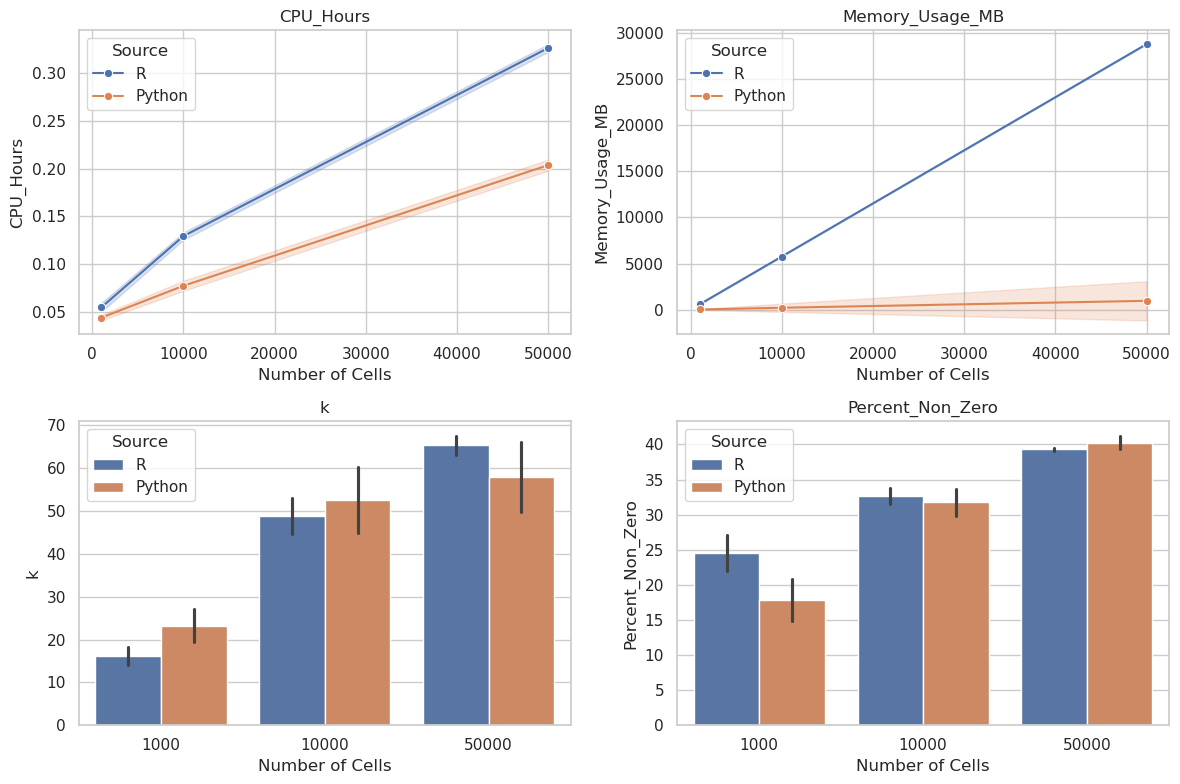

In [5]:
import math

def load_and_plot_benchmarks(csv_r_path, csv_py_path, n_run):
    # Load the benchmark CSV files
    df_r = pd.read_csv(csv_r_path)
    df_py = pd.read_csv(csv_py_path)

    # Add a 'Source' column to distinguish R and Python benchmarks
    df_r['Source'] = 'R'
    df_py['Source'] = 'Python'

    # Concatenate both DataFrames
    combined_df = pd.concat([df_r, df_py], ignore_index=True)

    # Prepare the melted DataFrame for plotting
    metrics = ['CPU_Hours', 'Memory_Usage_MB', 'k', 'Percent_Non_Zero']
    melted_df = pd.melt(
        combined_df,
        id_vars=['Source', 'Number_of_Cells', 'Run'],
        value_vars=metrics,
        var_name='Metric',
        value_name='Value'
    )

    # Set up the plot
    sns.set(style="whitegrid")

    # Combine metrics for layout calculation
    n_metrics = len(metrics)
    n_cols = 2  # Fixed number of columns
    n_rows = math.ceil(n_metrics / n_cols)

    plt.figure(figsize=(n_cols * 6, n_rows * 4))

    for i, metric in enumerate(metrics, 1):
        plt.subplot(n_rows, n_cols, i)

        if metric in ['CPU_Hours', 'Memory_Usage_MB']:  # Line plots
            sns.lineplot(
                data=melted_df[melted_df['Metric'] == metric],
                x='Number_of_Cells',
                y='Value',
                hue='Source',
                marker='o',
                ci='sd'  # Confidence interval based on standard deviation
            )
        else:  # Bar plots
            sns.barplot(
                data=melted_df[melted_df['Metric'] == metric],
                x='Number_of_Cells',
                y='Value',
                hue='Source',
                ci='sd'  # Confidence interval based on standard deviation
            )

        plt.title(metric)
        plt.xlabel('Number of Cells')
        plt.ylabel(metric)
        plt.legend(title='Source')

    plt.tight_layout()
    plt.show()

# Example usage
csv_r_path = "/storage/Implem/pyALRA_package/pyALRA/alra_benchmark_results/R/E-GEOD-139324/alra_benchmark_results.csv"
csv_py_path = "/storage/Implem/pyALRA_package/pyALRA/alra_benchmark_results/python/E-GEOD-139324/alra_benchmark_results.csv"
n_run = 5  # Number of repetitions
load_and_plot_benchmarks(csv_r_path, csv_py_path, n_run)